**Example 1:** 
The Failing Approach (No Reducer + Race Condition)
In this version, we tell the graph to go in two directions (Fan-out), but we don't give it a way to merge the data.

**The Issue:** Because state is a simple List, Node B and Node C will both try to overwrite the same key at the same time. LangGraph will throw an InvalidUpdateError because it doesn't know which one "wins."

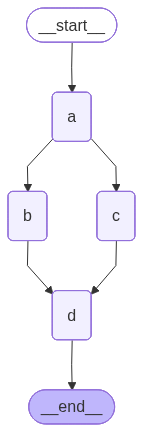

--- Executing Example 1 (No Reducer) ---
  Node A is running... Seen so far: []
  Node B is running... Seen so far: ['A']
  Node C is running... Seen so far: ['A']

❌ CRASHED: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CONCURRENT_GRAPH_UPDATE
REASON: B and C tried to update 'state' at the same time, and they conflicted!


In [1]:
from typing import List, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.errors import InvalidUpdateError

# PROBLEM: No Reducer. The graph can only "Replace", not "Append".
class State(TypedDict):
    state: List[str]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret
    def __call__(self, state: State) -> Any:
        print(f"  Node {self._value} is running... Seen so far: {state['state']}")
        return {"state": [self._value]}

builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("A"))
builder.add_node("b", ReturnNodeValue("B"))
builder.add_node("c", ReturnNodeValue("C"))
builder.add_node("d", ReturnNodeValue("D"))

builder.add_edge(START, "a")
# --- FAN-OUT STEP ---
# Concept: One source node triggers multiple target nodes simultaneously.
builder.add_edge("a", "b") 
builder.add_edge("a", "c") 

builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

print("--- Executing Example 1 (No Reducer) ---")
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"\n❌ CRASHED: {e}")
    print("REASON: B and C tried to update 'state' at the same time, and they conflicted!")


**Example 2:** The Successful Approach (Reducer + Fan-in Sync)
In this version, we use Annotated and operator.add. This is the "Reducer" that tells LangGraph: "When multiple updates arrive, just add them all to the list." We also use the Fan-in syntax to make Node D wait.

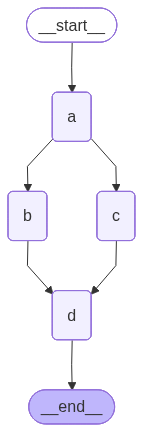


--- Executing Example 2 (With Reducer & Sync) ---
  Node A is running... Seen so far: []
  Node B is running... Seen so far: ['A']
  Node C is running... Seen so far: ['A']
  Node D is running... Seen so far: ['A', 'B', 'C']

✅ SUCCESS! Final State: A -> B -> C -> D


In [2]:
import operator
from typing import Annotated, List, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    state: Annotated[List[str], operator.add]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret
    def __call__(self, state: State) -> Any:
        print(f"  Node {self._value} is running... Seen so far: {state['state']}")
        return {"state": [self._value]}

builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("A"))
builder.add_node("b", ReturnNodeValue("B"))
builder.add_node("c", ReturnNodeValue("C"))
builder.add_node("d", ReturnNodeValue("D"))

builder.add_edge(START, "a")

# --- 1. FAN-OUT (Expanding Flow)---
# In LangGraph, you call add_edge twice to fan out. 
# This tells 'a' to trigger both 'b' AND 'c'.
builder.add_edge("a", "b") 
builder.add_edge("a", "c") 

# --- 2. FAN-IN (Consolidating Flow)---
# The syntax builder.add_edge([list], "target") IS supported 
# to create the synchronization (wait) point.
builder.add_edge(["b", "c"], "d") 

builder.add_edge("d", END)
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

print("\n--- Executing Example 2 (With Reducer & Sync) ---")
result = graph.invoke({"state": []})
print(f"\n✅ SUCCESS! Final State: {' -> '.join(result['state'])}")

### Healthcare Diagnostic Case Study:
#### Topic: Multi-Modal Patient Triage & Diagnostics
- In high-pressure environments like Emergency Rooms, time-to-diagnosis is a critical metric. 
- This use case demonstrates how Agentic AI moves beyond simple chatbots to become a "Clinical Decision Support System." 
- Instead of processing medical tests sequentially, the system utilizes Fan-out/Fan-in architecture to orchestrate multiple specialized agents simultaneously.

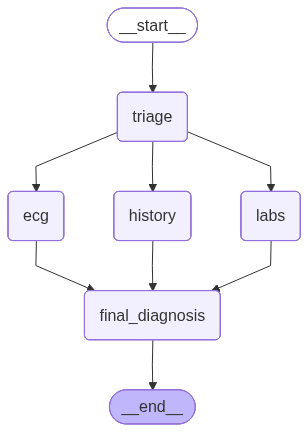

In [3]:
import operator
from typing import Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# THE KEY: 'Annotated[list, operator.add]' allows parallel nodes to 
# 'append' their results to the same list without overwriting each other.
class DiagnosticState(TypedDict):
    patient_id: str
    reports: Annotated[List[str], operator.add]
    critical_alert: bool

# --- Nodes ---
def triage_node(state: DiagnosticState):
    print("--- [Node A] Triage: Patient P-402 admitted with Chest Pain ---")
    return {"patient_id": "P-402", "reports": ["Triage: High Priority Case"]}

def ecg_analysis(state: DiagnosticState):
    print("--- [Node B] ECG Analyst: Checking waveforms... ---")
    return {"reports": ["ECG: Abnormal ST-segment detected"]}

def lab_results(state: DiagnosticState):
    print("--- [Node C] Lab Agent: Checking Troponin levels... ---")
    return {"reports": ["LAB: Elevated Troponin detected"]}

def medical_history(state: DiagnosticState):
    print("--- [Node D] History Agent: Fetching pre-existing records... ---")
    return {"reports": ["HISTORY: Patient has 2021 stent placement"]}

def finalize_diagnosis(state: DiagnosticState):
    print("--- [Node E] Aggregator: Synthesizing Final Report ---")
    # All findings are now in state["reports"]
    is_critical = any("Elevated" in r or "Abnormal" in r for r in state["reports"])
    return {"critical_alert": is_critical}

# --- Graph Construction ---
builder = StateGraph(DiagnosticState)

builder.add_node("triage", triage_node)
builder.add_node("ecg", ecg_analysis)
builder.add_node("labs", lab_results)
builder.add_node("history", medical_history)
builder.add_node("final_diagnosis", finalize_diagnosis)

# FLOW LOGIC
builder.add_edge(START, "triage")

# FAN-OUT: One edge to multiple targets creates parallel execution
builder.add_edge("triage", "ecg")
builder.add_edge("triage", "labs")
builder.add_edge("triage", "history")

# FAN-IN: Wait for all three to merge before the final node
builder.add_edge(["ecg", "labs", "history"], "final_diagnosis")

builder.add_edge("final_diagnosis", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# The initial input must match the keys in your DiagnosticState TypedDict
initial_input = {
    "patient_id": "P-402",
    "reports": [], # Start with an empty list for the parallel nodes to fill
    "critical_alert": False
}

# Run the graph synchronously
final_state = graph.invoke(initial_input)

# Print the aggregated results
print(f"Final Diagnosis for {final_state['patient_id']}:")
for report in final_state['reports']:
    print(f"- {report}")

print(f"Critical Status: {'🚨 EMERGENCY' if final_state['critical_alert'] else 'Normal'}")

--- [Node A] Triage: Patient P-402 admitted with Chest Pain ---
--- [Node B] ECG Analyst: Checking waveforms... ---
--- [Node D] History Agent: Fetching pre-existing records... ---
--- [Node C] Lab Agent: Checking Troponin levels... ---
--- [Node E] Aggregator: Synthesizing Final Report ---
Final Diagnosis for P-402:
- Triage: High Priority Case
- ECG: Abnormal ST-segment detected
- HISTORY: Patient has 2021 stent placement
- LAB: Elevated Troponin detected
Critical Status: 🚨 EMERGENCY
